In [9]:
import pandas as pd
import matplotlib as plt
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
import pipline as pl
import pandas as pd
from tqdm import tqdm
from tqdm_joblib import tqdm_joblib
from IPython import get_ipython
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv("housing.csv")

# Funktioner 
sorry programerade dessa i olika python filer sedan läste jag upgiten igen så stog det att jag skulle bara ha två dokument så jag tog beslutet istället för att börja om allt så klistar in funktionerna här.

In [10]:

def running_in_jupyter(): #fungerade inte i jupter book som jag ville så jag la in detta för att bypassa progressbaren i notebook
    
    try:
        shell = get_ipython().__class__.__name__
        
        if shell == "ZMQInteractiveShell":
            return True   
        else:
            return False # Jupyter Notebook / JupyterLab
    except:
        
        return False
    
def baseline_model(preprocessor):
    return pl.create_pipeline(preprocessor,LogisticRegression(max_iter=1000))

def random_forest_model(preprocessor,random_state = 42):
    return pl.create_pipeline(preprocessor,RandomForestClassifier(random_state=random_state))

def gradient_boosting_model(preprocessor,random_state = 42): #för skoj skull hittade jag denna och ville testa https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingClassifier.html
    return pl.create_pipeline(preprocessor, GradientBoostingClassifier(random_state = random_state))



def cross_validation(X_train, y_train, models
 ):
    results = {}

    for name, model in models.items():
        scores = cross_val_score(
            model,
            X_train,
            y_train,
            cv=5,
            scoring="f1"
        )
        
        results[name] = scores.mean()
    return results

def tune_random_forest(rf_model, X_train, y_train):

    param_grid = {
        "model__n_estimators": [300,500],
        "model__max_depth": [20,30],
        "model__min_samples_split": [5,8],
        "model__min_samples_leaf": [1, 2]
    }
    
    total_sum = 1
    for i in param_grid:
        total_sum = total_sum * len(param_grid[i])
    total_sum = total_sum*5

    grid_search = GridSearchCV(
        rf_model,
        param_grid,
        cv=5,
        scoring="f1",
        n_jobs=-1,
        verbose= 0
    )
    
    
    if not running_in_jupyter():  # bara för skoj skull och tyckte att det skulle vara använd bart men pga utav multiproccesor så fungerar detta inte med jupterbook...
        print("Runing natvie")
        with tqdm_joblib(tqdm(desc="GridSearch progress", total = total_sum )):
            grid_search.fit(X_train, y_train)
    else:
        print("runing in jupter")
        grid_search.fit(X_train, y_train)
    return grid_search

def train_test_split_for_model(
        df: pd.DataFrame= pd.read_csv("housing.csv"),
        target_column="high_value",
        price_column="median_house_value",
        test_size=0.2,
        random_state=42
    ):
    df = df.copy()
    
    if target_column not in df.columns:
        threshold = df[price_column].quantile(0.8)
        df[target_column] = (df[price_column] >= threshold).astype(int)

    X = df.drop(columns=[price_column, target_column])
    y = df[target_column]


    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        stratify=y,
        random_state=random_state
    )

    return X_train, X_test, y_train, y_test

def create_preprocessor():

    numeric_features = [
        "longitude",
        "latitude",
        "housing_median_age",
        "total_rooms",
        "total_bedrooms",
        "population",
        "households",
        "median_income"
    ]

    categorical_features = ["ocean_proximity"]

    numeric_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ])

    preprocessor = ColumnTransformer([
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ])

    return preprocessor

def create_pipeline(preprocessor,model):
    pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", model)
    ])
    return pipeline



# EDA

In [11]:

print(df.head())


   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  


In [12]:

print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB
None


In [13]:
missing = df.isna().sum()
missing_percent = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing values": missing,
    "Percent": missing_percent
}).sort_values("Percent", ascending=False)

print(missing_df)

                    Missing values   Percent
total_bedrooms                 207  1.002907
longitude                        0  0.000000
latitude                         0  0.000000
housing_median_age               0  0.000000
total_rooms                      0  0.000000
population                       0  0.000000
households                       0  0.000000
median_income                    0  0.000000
median_house_value               0  0.000000
ocean_proximity                  0  0.000000


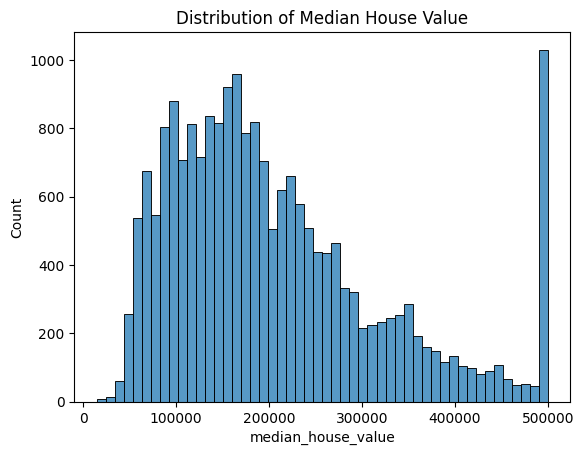

In [14]:
sns.histplot(df["median_house_value"], bins=50)
plt.title("Distribution of Median House Value")
plt.show()

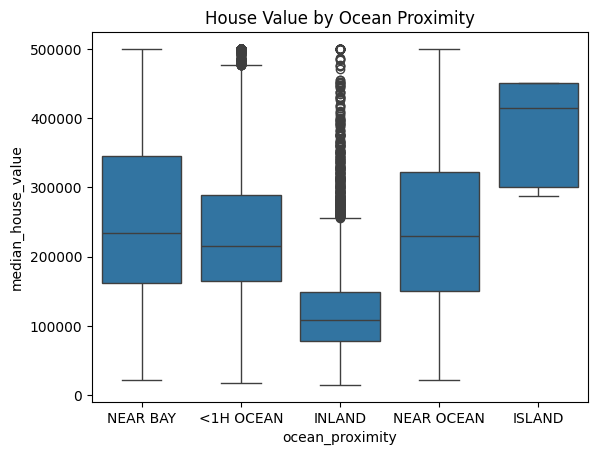

In [15]:
sns.boxplot(x="ocean_proximity", y="median_house_value", data=df)
plt.title("House Value by Ocean Proximity")
plt.show()

## pipline och model träning

In [16]:
X_train, X_test, y_train, y_test = pl.train_test_split_for_model()
preprocessor = pl.create_preprocessor()

blm = baseline_model(pl.create_preprocessor())
rfm= random_forest_model(pl.create_preprocessor())
gbm  = gradient_boosting_model(pl.create_preprocessor())
models ={"Baseline LogisticRegression Model":blm,"Random forest Model":rfm,"Gradient boosting model":gbm}
results = cross_validation(X_train, y_train,models )

print(results)

{'Baseline LogisticRegression Model': np.float64(0.6981110417043386), 'Random forest Model': np.float64(0.7823766220564364), 'Gradient boosting model': np.float64(0.7635091830735797)}


## Random Forest Optermering

In [17]:
results = tune_random_forest(rfm,X_train, y_train)


runing in jupter


In [18]:
print(cross_validation(X_train,y_train,{"Random forest": rfm,"Tuned Random forest":results.best_estimator_ }))
print(results.best_params_)

{'Random forest': np.float64(0.7823766220564364), 'Tuned Random forest': np.float64(0.7889711427518109)}
{'model__max_depth': 20, 'model__min_samples_leaf': 1, 'model__min_samples_split': 5, 'model__n_estimators': 500}


In [19]:
best_model = results.best_estimator_

y_pred = best_model.predict(X_test)

print(classification_report(y_test, y_pred)) # https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html

              precision    recall  f1-score   support

           0       0.93      0.97      0.95      3302
           1       0.85      0.69      0.76       826

    accuracy                           0.91      4128
   macro avg       0.89      0.83      0.85      4128
weighted avg       0.91      0.91      0.91      4128

